In [ ]:
import cv2
import numpy as np
from pydicom import dcmread
import os
import SimpleITK as sitk
import pandas as pd
from radiomics import featureextractor


name = "Mario_D'Oria_ADX_ITA_PHILIPS_2.000"
condition = "ADX"

dicom_path = "".join(["CT_dicom/",condition,"/",name])
mask_path = "".join(["CT_mask/",condition,"/",name,"/aorta.nii.gz"])

# 2. Read all DICOM files from the folder
dicom_slices = []
for filename in os.listdir(dicom_path):
    filepath = os.path.join(dicom_path, filename)
    
    # Skip subdirectories if any exist
    if os.path.isdir(filepath):
        continue
        
        # Read the file
    dataset = dcmread(filepath)
        
        # Make sure the file actually contains image data before adding it
    dicom_slices.append(dataset)
    continue

# 3. Sort the slices spatially using the Z-coordinate of the patient position
# This ensures your 3D volume is stacked exactly how the patient was scanned
dicom_slices.sort(key=lambda x: x.ImagePositionPatient[2], reverse=True)

def get_hu_image(dataset):
    # Load pixel data
    image = dataset.pixel_array.astype(np.int16)
    
    # Apply rescale intercept/slope from headers
    intercept = dataset.RescaleIntercept
    slope = dataset.RescaleSlope
    
    if slope != 1:
        image = slope * image.astype(np.float64)
        image = image.astype(np.int16)
        
    image += np.int16(intercept)
    return np.array(image, dtype=np.int16)

def process_slice(image):
    min_hu, max_hu = -50, 100
    image_clipped = np.clip(image, min_hu, max_hu)
    # Normalización 0-1
    image_norm = (image_clipped - min_hu) / (max_hu - min_hu)
    return image_norm


hu_slices = []
for dataset in dicom_slices:
    # Get HU converted image
    hu_slice = get_hu_image(dataset)
    # Process the slice
    hu_slice = process_slice(hu_slice)
    
    # Resize
    resized_slice = cv2.resize(hu_slice, (512, 512), interpolation=cv2.INTER_LINEAR)
    hu_slices.append(resized_slice)

# 5. Stack into the final 3D volume
hu_volume = np.stack(hu_slices, axis=0)
hu_volume=hu_volume[::-1]  # Invert the volume along the first axis

print(f"Successfully loaded and stacked {hu_volume.shape[0]} slices.")
print(f"Volume shape: {hu_volume.shape}")

mask = sitk.ReadImage((mask_path))

extractor = featureextractor.RadiomicsFeatureExtractor()
image = sitk.GetImageFromArray(hu_volume)
image.SetSpacing(mask.GetSpacing())
image.SetOrigin(mask.GetOrigin())
features= extractor.execute(image,mask)

# Pass the dictionary inside a list to create a single-row DataFrame
df = pd.DataFrame([features])

# Save to CSV without the index column
df.to_csv(("".join(["features/",condition,"/",name,"_pyradiomics.csv"])), index=False)

Successfully loaded and stacked 771 slices.
Volume shape: (771, 512, 512)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Text(0.5, 1.0, 'Isolated ROI')

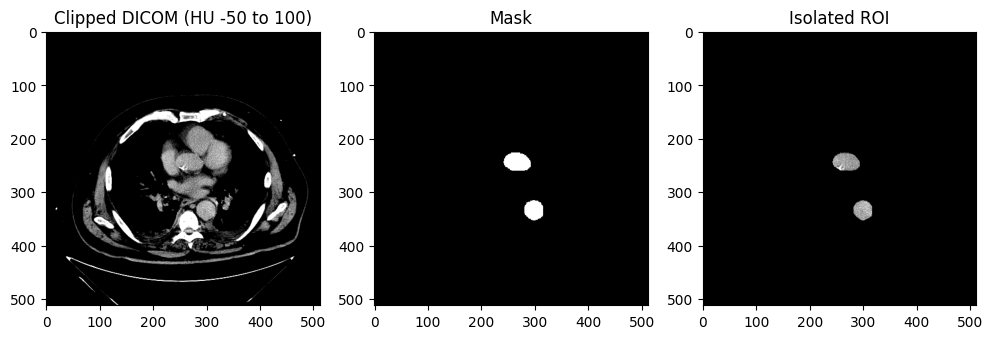

In [21]:
from matplotlib import pyplot as plt
target_slice = 575

mask_array = sitk.GetArrayFromImage(mask)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(hu_volume[target_slice,:, :], cmap='gray')
plt.title('Clipped DICOM (HU -50 to 100)')

plt.subplot(1, 3, 2)
plt.imshow(mask_array[target_slice,:, :], cmap='gray')
plt.title('Mask')

isolated_slice = np.where(mask_array[target_slice,:, :] > 0, hu_volume[target_slice,:, :], 0)

plt.subplot(1, 3, 3)
plt.imshow(isolated_slice, cmap='gray')
plt.title('Isolated ROI')
